<a href="https://colab.research.google.com/github/kridtapon/Silent-Reversion-Strategy/blob/main/Silent_Reversion_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install vectorbt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.6/527.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.1 MB/s eta 0:00:00


In [ ]:
pip install --upgrade yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.8/113.8 kB 2.0 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.56
    Uninstalling yfinance-0.2.56:
      Successfully uninstalled yfinance-0.2.56


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import vectorbt as vbt

# Function to calculate Z-score for mean reversion strategy
def calculate_z_score(series, window=20):
    mean = series.rolling(window=window).mean()
    std = series.rolling(window=window).std()
    z_score = (series - mean) / std
    return z_score

# Function to calculate ATR (Average True Range)
def calculate_atr(df, window=14):
    high_low = df['High'] - df['Low']
    high_close = np.abs(df['High'] - df['Close'].shift(1))
    low_close = np.abs(df['Low'] - df['Close'].shift(1))
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    atr = true_range.rolling(window=window).mean()
    return atr

# Define the stock symbol and time period
symbol = 'UAL'
start_date = '2019-01-01'
end_date = '2025-01-01'

# Download the data
df = yf.download(symbol, start=start_date, end=end_date, multi_level_index=False)

# Calculate Z-score based on the closing price
df['Z'] = calculate_z_score(df['Close'], window=20)

# Calculate ATR
df['ATR'] = calculate_atr(df, window=14)

# Volatility filter: ATR must be lower than its 50-day median
atr_median = df['ATR'].rolling(window=50).median()
df['Low_Volatility'] = df['ATR'] < atr_median

# Filter data for the test period (2020-2025)
df = df[(df.index.year >= 2020) & (df.index.year <= 2025)]

# Entry and Exit conditions with Volatility filter applied
df['Entry'] = (df['Z'] < -2) & (df['Low_Volatility'])  # Buy signal
df['Exit'] = (df['Z'] > 2) # Exit signal (no volatility filter needed for exit)

# Shift entries and exits to next bar
shifted_entries = df['Entry'].shift(1).fillna(False).astype(bool).to_numpy()
shifted_exits = df['Exit'].shift(1).fillna(False).astype(bool).to_numpy()

# Create portfolio using 'Open' prices
portfolio = vbt.Portfolio.from_signals(
    close=df['Open'],
    entries=shifted_entries,
    exits=shifted_exits,
    init_cash=100_000,
    fees=0.001,
    slippage=0.002,
    freq='D'
)

# Display performance metrics
print(portfolio.stats())

# Plot equity curve
portfolio.plot().show()


[*********************100%***********************]  1 of 1 completed
<ipython-input-6-3c826ac23b6b>:48: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

<ipython-input-6-3c826ac23b6b>:49: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Start                                2020-01-02 00:00:00
End                                  2024-12-31 00:00:00
Period                                1258 days 00:00:00
Start Value                                     100000.0
End Value                                  229098.145216
Total Return [%]                              129.098145
Benchmark Return [%]                            9.210673
Max Gross Exposure [%]                             100.0
Total Fees Paid                              3834.559912
Max Drawdown [%]                               35.096519
Max Drawdown Duration                  335 days 00:00:00
Total Trades                                          10
Total Closed Trades                                   10
Total Open Trades                                      0
Open Trade PnL                                       0.0
Win Rate [%]                                        90.0
Best Trade [%]                                  23.24733
Worst Trade [%]                

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import vectorbt as vbt
import itertools

# ------------------------------
# Indicator calculation function
# ------------------------------
def calculate_indicators(df, z_window, atr_window, atr_median_window):
    df = df.copy()

    # Z-score
    df['Z'] = (df['Close'] - df['Close'].rolling(window=z_window).mean()) / df['Close'].rolling(window=z_window).std()

    # ATR
    high_low = df['High'] - df['Low']
    high_close = np.abs(df['High'] - df['Close'].shift(1))
    low_close = np.abs(df['Low'] - df['Close'].shift(1))
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df['ATR'] = true_range.rolling(window=atr_window).mean()

    # Volatility filter
    df['Low_Volatility'] = df['ATR'] < df['ATR'].rolling(window=atr_median_window).median()

    return df

# ------------------------------
# Optimization Setup
# ------------------------------
z_windows = [10, 15, 20, 25, 30]
atr_windows = [10, 14, 20]
atr_median_windows = [30, 50, 70]

symbol = 'UAL'
start_date = '2019-01-01'
end_date = '2025-01-01'

# Download data
df_raw = yf.download(symbol, start=start_date, end=end_date, multi_level_index=False)

# ------------------------------
# Optimization Loop
# ------------------------------
results = []

for z_w, atr_w, atr_median_w in itertools.product(z_windows, atr_windows, atr_median_windows):
    df = calculate_indicators(df_raw, z_w, atr_w, atr_median_w)

    df_test = df[(df.index.year >= 2020) & (df.index.year <= 2025)]

    df_test['Entry'] = (df_test['Z'] < -2) & (df_test['Low_Volatility'])
    df_test['Exit'] = (df_test['Z'] > 2)

    entries = df_test['Entry'].shift(1).fillna(False).astype(bool).to_numpy()
    exits = df_test['Exit'].shift(1).fillna(False).astype(bool).to_numpy()

    try:
        portfolio = vbt.Portfolio.from_signals(
            close=df_test['Open'],
            entries=entries,
            exits=exits,
            init_cash=100_000,
            fees=0.001,
            slippage=0.002,
            freq='D'
        )
        total_return = portfolio.total_return()
        results.append((z_w, atr_w, atr_median_w, total_return))
    except Exception as e:
        print(f"Error for combination z:{z_w}, atr:{atr_w}, median:{atr_median_w}: {e}")

# ------------------------------
# Results Summary
# ------------------------------
results_df = pd.DataFrame(results, columns=['Z_Window', 'ATR_Window', 'ATR_Median_Window', 'Total Return [%]'])
best = results_df.sort_values(by='Total Return [%]', ascending=False).head(5)

print("Top 5 parameter combinations by Total Return [%]:")
print(best)


[*********************100%***********************]  1 of 1 completed
<ipython-input-7-b6280838673f>:52: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-7-b6280838673f>:53: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-7-b6280838673f>:55: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_do

Top 5 parameter combinations by Total Return [%]:
    Z_Window  ATR_Window  ATR_Median_Window  Total Return [%]
33        25          20                 30          2.550834
31        25          14                 50          2.550834
35        25          20                 70          2.526431
34        25          20                 50          2.480457
32        25          14                 70          2.299162


<ipython-input-7-b6280838673f>:52: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-7-b6280838673f>:53: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-7-b6280838673f>:55: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

<ipython-input-7-b6280838673f>:56: FutureWarning:

Streaming output truncated to the last 5000 lines.
<ipython-input-17-76fe52abccd4>:60: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

<ipython-input-17-76fe52abccd4>:61: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

<ipython-input-17-76fe52abccd4>:57: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-17-7

Best parameter combination by Total Return [%]:
       Z_Window  ATR_Window  ATR_Median_Window  Total Return [%]
48714        25          20                 39          3.117434

Backtest Performance with Best Parameters:
Start                                2020-01-02 00:00:00
End                                  2024-12-31 00:00:00
Period                                1258 days 00:00:00
Start Value                                     100000.0
End Value                                   411743.44516
Total Return [%]                              311.743445
Benchmark Return [%]                            9.210673
Max Gross Exposure [%]                             100.0
Total Fees Paid                               5473.41286
Max Drawdown [%]                               32.165479
Max Drawdown Duration                  335 days 00:00:00
Total Trades                                           9
Total Closed Trades                                    9
Total Open Trades                    

<ipython-input-17-76fe52abccd4>:96: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-17-76fe52abccd4>:97: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-17-76fe52abccd4>:99: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

<ipython-input-17-76fe52abccd4>:100: FutureWar

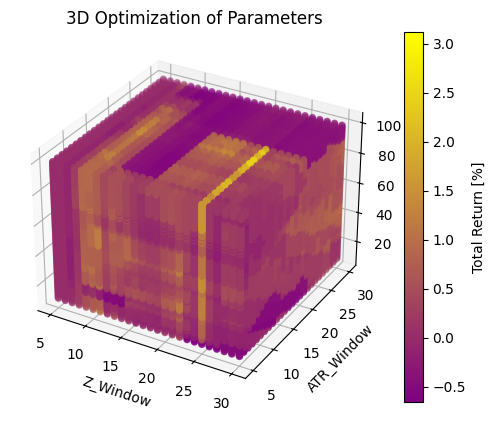

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import vectorbt as vbt
import itertools
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------
# Indicator calculation function
# ------------------------------
def calculate_indicators(df, z_window, atr_window, atr_median_window):
    df = df.copy()
    z_window = int(z_window)
    atr_window = int(atr_window)
    atr_median_window = int(atr_median_window)

    # Z-score
    df['Z'] = (df['Close'] - df['Close'].rolling(window=z_window).mean()) / df['Close'].rolling(window=z_window).std()

    # ATR
    high_low = df['High'] - df['Low']
    high_close = np.abs(df['High'] - df['Close'].shift(1))
    low_close = np.abs(df['Low'] - df['Close'].shift(1))
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df['ATR'] = true_range.rolling(window=atr_window).mean()

    # Volatility filter
    df['Low_Volatility'] = df['ATR'] < df['ATR'].rolling(window=atr_median_window).median()

    return df

# ------------------------------
# Optimization Setup
# ------------------------------
z_windows = range(5, 31)
atr_windows = range(5, 31)
atr_median_windows = range(10, 101)

symbol = 'UAL'
start_date = '2019-01-01'
end_date = '2025-01-01'

# Download data
df_raw = yf.download(symbol, start=start_date, end=end_date, multi_level_index=False)

# ------------------------------
# Optimization Loop
# ------------------------------
results = []

for z_w, atr_w, atr_median_w in itertools.product(z_windows, atr_windows, atr_median_windows):
    df = calculate_indicators(df_raw, z_w, atr_w, atr_median_w)

    df_test = df[(df.index.year >= 2020) & (df.index.year <= 2025)]

    df_test['Entry'] = (df_test['Z'] < -2) & (df_test['Low_Volatility'])
    df_test['Exit'] = (df_test['Z'] > 2)

    entries = df_test['Entry'].shift(1).fillna(False).astype(bool).to_numpy()
    exits = df_test['Exit'].shift(1).fillna(False).astype(bool).to_numpy()

    try:
        portfolio = vbt.Portfolio.from_signals(
            close=df_test['Open'],
            entries=entries,
            exits=exits,
            init_cash=100_000,
            fees=0.001,
            slippage=0.002,
            freq='D'
        )
        total_return = portfolio.total_return()
        results.append((z_w, atr_w, atr_median_w, total_return))
    except Exception as e:
        print(f"Error for combination z:{z_w}, atr:{atr_w}, median:{atr_median_w}: {e}")

# ------------------------------
# Results Summary
# ------------------------------
results_df = pd.DataFrame(results, columns=['Z_Window', 'ATR_Window', 'ATR_Median_Window', 'Total Return [%]'])
best = results_df.sort_values(by='Total Return [%]', ascending=False).head(1)

print("Best parameter combination by Total Return [%]:")
print(best)

# ------------------------------
# Backtest with Best Parameters
# ------------------------------
best_params = best.iloc[0][['Z_Window', 'ATR_Window', 'ATR_Median_Window']]

df_best = calculate_indicators(df_raw, best_params['Z_Window'], best_params['ATR_Window'], best_params['ATR_Median_Window'])

df_best_test = df_best[(df_best.index.year >= 2020) & (df_best.index.year <= 2025)]

df_best_test['Entry'] = (df_best_test['Z'] < -2) & (df_best_test['Low_Volatility'])
df_best_test['Exit'] = (df_best_test['Z'] > 2)

entries_best = df_best_test['Entry'].shift(1).fillna(False).astype(bool).to_numpy()
exits_best = df_best_test['Exit'].shift(1).fillna(False).astype(bool).to_numpy()

portfolio_best = vbt.Portfolio.from_signals(
    close=df_best_test['Open'],
    entries=entries_best,
    exits=exits_best,
    init_cash=100_000,
    fees=0.001,
    slippage=0.002,
    freq='D'
)

print("\nBacktest Performance with Best Parameters:")
print(portfolio_best.stats())
portfolio_best.plot().show()

# ------------------------------
# 3D Plot of All Optimized Parameters
# ------------------------------
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Extract the optimized parameter combinations
x = results_df['Z_Window']
y = results_df['ATR_Window']
z = results_df['ATR_Median_Window']
total_returns = results_df['Total Return [%]']

# Define a custom colormap from purple to yellow
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("purple_yellow", ["purple", "yellow"])

# Plot the 3D scatter plot with the new colormap
sc = ax.scatter(x, y, z, c=total_returns, cmap=cmap, marker='o')

# Add color bar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Total Return [%]')

# Set labels and title
ax.set_xlabel('Z_Window')
ax.set_ylabel('ATR_Window')
ax.set_zlabel('ATR_Median_Window')
ax.set_title('3D Optimization of Parameters')

# Show the plot
plt.show()




[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['UAL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


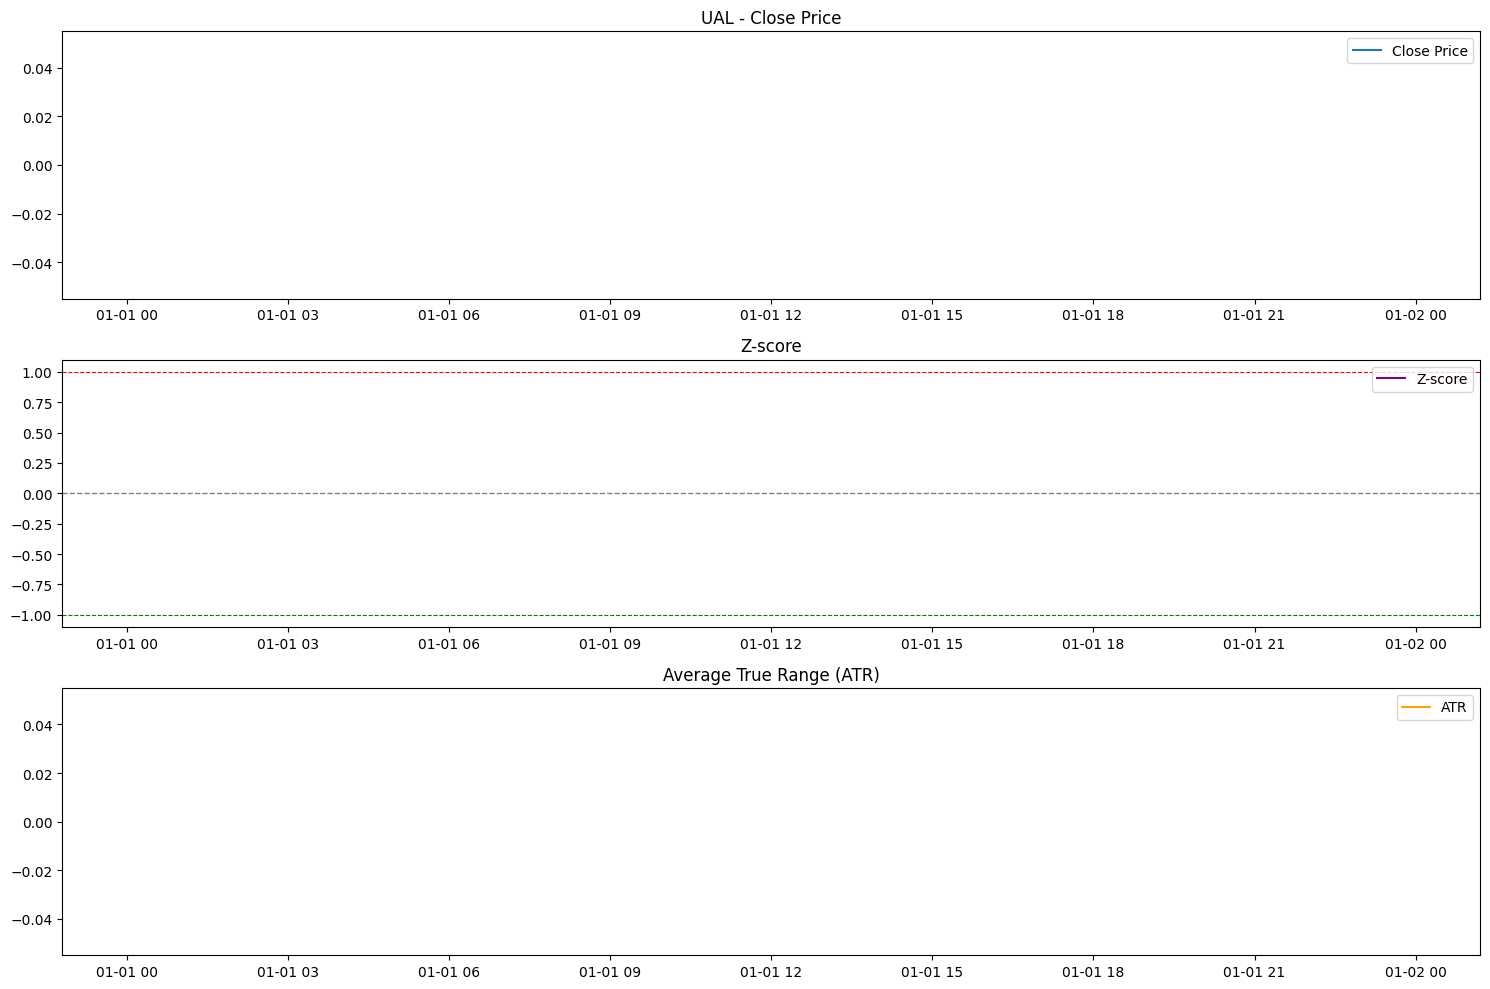

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Indicator calculation function
def calculate_indicators(df, z_window, atr_window, atr_median_window):
    df = df.copy()
    z_window = int(z_window)
    atr_window = int(atr_window)
    atr_median_window = int(atr_median_window)

    # Z-score
    df['Z'] = (df['Close'] - df['Close'].rolling(window=z_window).mean()) / df['Close'].rolling(window=z_window).std()

    # ATR
    high_low = df['High'] - df['Low']
    high_close = np.abs(df['High'] - df['Close'].shift(1))
    low_close = np.abs(df['Low'] - df['Close'].shift(1))
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df['ATR'] = true_range.rolling(window=atr_window).mean()

    # Volatility filter
    df['Low_Volatility'] = df['ATR'] < df['ATR'].rolling(window=atr_median_window).median()

    return df

# Download data
symbol = 'UAL'
start_date = '2020-01-01'
end_date = '2025-01-01'
df_raw = yf.download(symbol, start=start_date, end=end_date, multi_level_index=False)

# Calculate indicators
z_window = 20
atr_window = 14
atr_median_window = 30
df = calculate_indicators(df_raw, z_window, atr_window, atr_median_window)

# Plot
plt.figure(figsize=(15, 10))

# Close price
plt.subplot(3, 1, 1)
plt.plot(df.index, df['Close'], label='Close Price')
plt.title(f'{symbol} - Close Price')
plt.legend()

# Z-score
plt.subplot(3, 1, 2)
plt.plot(df.index, df['Z'], label='Z-score', color='purple')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axhline(1, color='red', linestyle='--', linewidth=0.8)
plt.axhline(-1, color='green', linestyle='--', linewidth=0.8)
plt.title('Z-score')
plt.legend()

# ATR
plt.subplot(3, 1, 3)
plt.plot(df.index, df['ATR'], label='ATR', color='orange')
plt.title('Average True Range (ATR)')
plt.legend()

plt.tight_layout()
plt.show()
